In [12]:

import json
from collections import defaultdict
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm

# Path to the chunks file
chunks_path = '../data/processed/danish_final_cluster/merged/chunks.jsonl'

# Load chunks and group by doc_id
doc_chunks = defaultdict(list)
with open(chunks_path, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        entry = json.loads(line)
        chunk_id = entry['chunk_id']
        context_ids = entry['explicit_context_chunks']
        chunk_text = entry['chunk']
        doc_id = chunk_id.split('_')[0]
        doc_chunks[doc_id].append((chunk_id, context_ids, chunk_text))

print(f"Loaded {len(doc_chunks)} documents.")
for doc_id, chunks in doc_chunks.items():
    print(f"{doc_id}: {len(chunks)} chunks")


Loaded 7 documents.
almenboligloven: 1131 chunks
barnetslov: 777 chunks
serviceloven: 1325 chunks
aaregnskabsloven: 1327 chunks
erhversfondsloven: 523 chunks
selskabsloven: 1647 chunks
straffeloven: 1013 chunks


In [13]:
import tiktoken

# compute the amount of tokens per dataset
tokenizer = tiktoken.get_encoding("o200k_harmony")
doc_token_counts = {}
doc_word_counts = {}
for doc_id, chunks in doc_chunks.items():
    full_text = " ".join(chunk[-1] for chunk in chunks)
    tokens = tokenizer.encode(full_text)
    doc_token_counts[doc_id] = len(tokens)
    doc_word_counts[doc_id] = len(full_text.split())
# Print token counts
for doc_id, token_count in doc_token_counts.items():
    print(f"{doc_id}: {token_count} tokens")

for doc_id, word_count in doc_word_counts.items():
    print(f"{doc_id}: {word_count} words")
    

almenboligloven: 96645 tokens
barnetslov: 60033 tokens
serviceloven: 96845 tokens
aaregnskabsloven: 83934 tokens
erhversfondsloven: 34356 tokens
selskabsloven: 137621 tokens
straffeloven: 75036 tokens
almenboligloven: 46743 words
barnetslov: 31388 words
serviceloven: 49318 words
aaregnskabsloven: 39526 words
erhversfondsloven: 16767 words
selskabsloven: 65360 words
straffeloven: 38130 words


In [14]:
from transformers import AutoTokenizer

# Qwen3 tokenizer (shared across all Qwen3 model sizes)
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-235B-A22B-Instruct-2507-FP8")

qwen_doc_token_counts = {}
for doc_id, chunks in doc_chunks.items():
    full_text = " ".join(chunk[-1] for chunk in chunks)
    tokens = qwen_tokenizer.encode(full_text, add_special_tokens=False)
    qwen_doc_token_counts[doc_id] = len(tokens)

for doc_id, token_count in qwen_doc_token_counts.items():
    ratio = token_count / doc_token_counts[doc_id]
    print(f"{doc_id}: {token_count} tokens (Qwen3)  vs  {doc_token_counts[doc_id]} (o200k)  ratio={ratio:.2f}")

almenboligloven: 114716 tokens (Qwen3)  vs  96645 (o200k)  ratio=1.19
barnetslov: 71984 tokens (Qwen3)  vs  60033 (o200k)  ratio=1.20
serviceloven: 116108 tokens (Qwen3)  vs  96845 (o200k)  ratio=1.20
aaregnskabsloven: 102365 tokens (Qwen3)  vs  83934 (o200k)  ratio=1.22
erhversfondsloven: 40716 tokens (Qwen3)  vs  34356 (o200k)  ratio=1.19
selskabsloven: 165983 tokens (Qwen3)  vs  137621 (o200k)  ratio=1.21
straffeloven: 88987 tokens (Qwen3)  vs  75036 (o200k)  ratio=1.19


In [18]:
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from collections import defaultdict

# ── Config ───────────────────────────────────────────────────────────────────
CONTEXT_WINDOW = 264_400  # Qwen3-235B context window

DATASETS = {
    "danish_final_cluster":      "../data/processed/danish_final_cluster/merged/chunks.jsonl",
    # "danish_dataset_7_no_chain": "../data/processed/danish_dataset_7_no_chain/merged/chunks.jsonl",
    "polish_final_cluster":      "../data/processed/polish_final_cluster/merged/chunks.jsonl",
    # "polish_dataset_7_no_chain": "../data/processed/polish_dataset_7_no_chain/merged/chunks.jsonl",
}

# Static parts of the contextualisation prompt (from AnthropicContextualPreprocessor)
PROMPT_PREFIX = (
    "System: You are a precise context augmenter \n"
    "User:\n"
    "Goal: Give a context to situate this chunk in the context of the document for the purposes of improving search retrieval of the chunk\n"
    "Instructions: \n"
    "Please give a succinct context to situate this chunk within the "
    "overall document for the purposes of improving search retrieval of the chunk. "
    "Answer only with the context and nothing else."
    "Context: \n"
    "<document>\n"
)
PROMPT_BETWEEN = (
    "\n</document>\n"
    "Here is the chunk we want to situate within the whole document\n"
    "<chunk>\n"
)
PROMPT_SUFFIX = (
    "\n</chunk>\n"
    "Instructions reminder:\n"
    "Please give a succinct context to situate this chunk within the "
    "overall document for the purposes of improving search retrieval of the chunk. "
    "Answer only with the context and nothing else."
    "Answer in the language of the document. (Document and the chunk are in the same language)"
)

# qwen_tokenizer is already loaded in the cell above
tok = qwen_tokenizer

prefix_tokens   = len(tok.encode(PROMPT_PREFIX,  add_special_tokens=False))
between_tokens  = len(tok.encode(PROMPT_BETWEEN, add_special_tokens=False))
suffix_tokens   = len(tok.encode(PROMPT_SUFFIX,  add_special_tokens=False))
newline_tokens  = len(tok.encode("\n",            add_special_tokens=False))
static_overhead = prefix_tokens + between_tokens + suffix_tokens

print(f"Static prefix:         {prefix_tokens:,} tokens")
print(f"Static between:        {between_tokens:,} tokens")
print(f"Static suffix:         {suffix_tokens:,} tokens")
print(f"Newline separator:     {newline_tokens} token(s)")
print(f"Total static overhead: {static_overhead:,} tokens")

Static prefix:         81 tokens
Static between:        21 tokens
Static suffix:         60 tokens
Newline separator:     1 token(s)
Total static overhead: 162 tokens


In [19]:
def load_and_tokenize(jsonl_path, tokenizer):
    """Load chunks from JSONL, tokenize each, group by doc_id sorted by chunk_idx."""
    doc_chunks = defaultdict(list)
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            entry = json.loads(line)
            chunk_id   = entry["chunk_id"]
            chunk_idx  = entry.get("chunk_idx", 0)
            chunk_text = entry["chunk"]
            doc_id = chunk_id.split("_")[0]
            n_tok = len(tokenizer.encode(chunk_text, add_special_tokens=False))
            doc_chunks[doc_id].append((chunk_idx, n_tok))
    for doc_id in doc_chunks:
        doc_chunks[doc_id].sort(key=lambda x: x[0])
    return doc_chunks


all_datasets = {}
for ds_name, path in DATASETS.items():
    print(f"Tokenising {ds_name}...")
    all_datasets[ds_name] = load_and_tokenize(path, tok)
    n_docs   = len(all_datasets[ds_name])
    n_chunks = sum(len(v) for v in all_datasets[ds_name].values())
    print(f"  → {n_docs} docs, {n_chunks} chunks")

print("\nDone.")

Tokenising danish_final_cluster...
  → 7 docs, 7743 chunks
Tokenising polish_final_cluster...
  → 6 docs, 15198 chunks

Done.


danish_final_cluster: max chunk = 2,075 tokens
polish_final_cluster: max chunk = 881 tokens


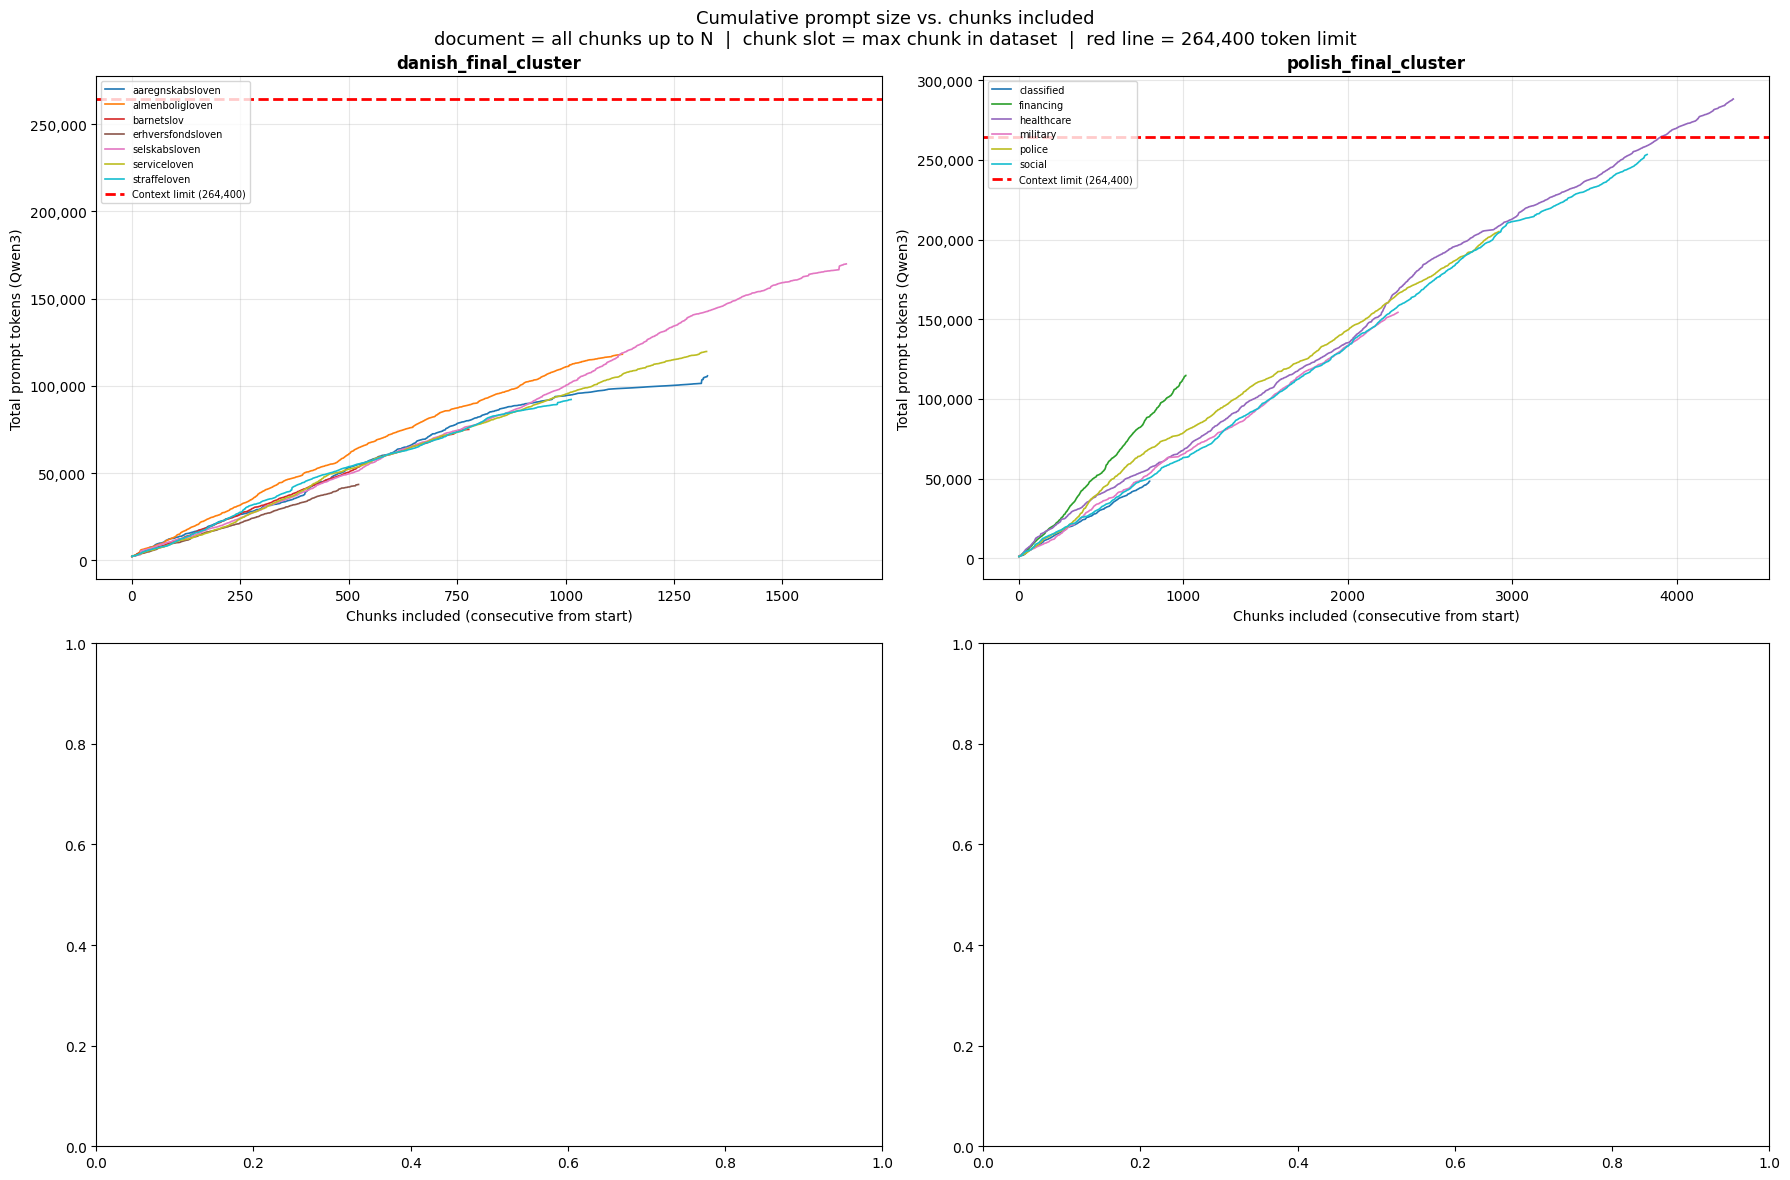

Saved cut_plot.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (ds_name, doc_chunks) in zip(axes, all_datasets.items()):
    # Max chunk token count in this dataset — kept constant as the "chunk" slot in the prompt
    max_chunk_tokens = max(n_tok for chunks in doc_chunks.values() for _, n_tok in chunks)
    print(f"{ds_name}: max chunk = {max_chunk_tokens:,} tokens")

    colors = cm.tab10(np.linspace(0, 1, len(doc_chunks)))
    for (doc_id, chunks), color in zip(sorted(doc_chunks.items()), colors):
        running_doc = 0
        xs, ys = [], []
        for i, (chunk_idx, n_tok) in enumerate(chunks):
            if i > 0:
                running_doc += newline_tokens  # "\n" separator between chunks
            running_doc += n_tok
            prompt_total = static_overhead + running_doc + max_chunk_tokens
            xs.append(i + 1)
            ys.append(prompt_total)
        ax.plot(xs, ys, label=doc_id, color=color, linewidth=1.2)

    ax.axhline(CONTEXT_WINDOW, color="red", linewidth=2, linestyle="--",
               label=f"Context limit ({CONTEXT_WINDOW:,})")
    ax.set_title(ds_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Chunks included (consecutive from start)")
    ax.set_ylabel("Total prompt tokens (Qwen3)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Cumulative prompt size vs. chunks included\n"
    f"document = all chunks up to N  |  chunk slot = max chunk in dataset  |  red line = {CONTEXT_WINDOW:,} token limit",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("cut_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved cut_plot.png")

In [22]:
# analyse if there are any chunks with explicit or implicit context that references to a chunk AFTER the position of the chunk
# compute the percentage for which it happens

from sympy.physics.units import l
for doc_id, chunks in doc_chunks.items():
    total = len([chunk for chunk in chunks if chunk[1]])  # only consider chunks with explicit context
    first_occurance = None
    last_occurance = None
    last_occurence_chunk = None
    count_ref_forward = 0
    index = 0

    for chunk_id, context_ids, chunk_text in chunks:
        chunk_idx = int(chunk_id.split('_')[-1])
        context_idxs = [int(cid.split('_')[-1]) for cid in context_ids]
        # context_idxs.append(chunk_idx)  # include the chunk itself as context
        if not context_idxs:
            continue  # skip if no explicit context
        if all(abs(ctx_idx-chunk_idx) < 300 for ctx_idx in context_idxs):
            count_ref_forward += 1
            if first_occurance is None:
                first_occurance = index / total
                # print(chunk_id, context_ids)
                # print(chunk_idx, context_idxs)
            last_occurance = index / total
            last_occurence_chunk = chunk_id
        index += 1
    percentage = (count_ref_forward / total) * 100 if total > 0 else 0
    print(f"{doc_id}: {percentage:.2f}% of chunks reference a chunk after their position")
    print(f"First occurence: {first_occurance:.3f} (percentile)")
    print(f"Last occurence: {last_occurance:.2f} (percentile) for chunk {last_occurence_chunk}")

        
    

education: 77.41% of chunks reference a chunk after their position
First occurence: 0.001 (percentile)
Last occurence: 1.00 (percentile) for chunk education_law_2449
financing: 85.68% of chunks reference a chunk after their position
First occurence: 0.000 (percentile)
Last occurence: 0.99 (percentile) for chunk financing_education_1010
highereducation: 70.73% of chunks reference a chunk after their position
First occurence: 0.000 (percentile)
Last occurence: 1.00 (percentile) for chunk highereducation_science_3642
classified: 90.10% of chunks reference a chunk after their position
First occurence: 0.000 (percentile)
Last occurence: 0.99 (percentile) for chunk classified_information_786
military: 88.34% of chunks reference a chunk after their position
First occurence: 0.000 (percentile)
Last occurence: 1.00 (percentile) for chunk military_2292
police: 86.56% of chunks reference a chunk after their position
First occurence: 0.000 (percentile)
Last occurence: 1.00 (percentile) for chunk p